# 🧪 AirLyst: [02] EDA & Cleaning
**Mission: Understand & Fix**

In this notebook, we perform a deep dive into our raw data. We will audit the structure, identify gaps in the time-series, analyze correlations between pollutants and weather, and finally clean the data for our ML pipeline.

---

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setup Path
ROOT_DIR = Path("C:/Users/Dell/Desktop/AirLyst")
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from backend.config.settings import settings

print(f" System Ready for EDA: {settings.APP_NAME}")

 System Ready for EDA: AirLyst AQI Predictor


## 📂 1. Data Audit (Loading & Inspection)
We load the raw CSV created in the previous step and check its basic properties.

In [2]:
data_path = ROOT_DIR / "backend/data/raw_historical_data.csv"
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'])

print("--[DATA AUDIT] ---")
print(f" Total Rows: {df.shape[0]}")
print(f" Total Features: {df.shape[1]}")
print(f" Time Range: {df['time'].min()} to {df['time'].max()}")

print("\n--- [COLUMN TYPES] ---")
print(df.dtypes)

df.head()

--[DATA AUDIT] ---
 Total Rows: 13176
 Total Features: 14
 Time Range: 2024-11-13 00:00:00 to 2026-05-15 23:00:00

--- [COLUMN TYPES] ---
time                    datetime64[ns]
pm10                           float64
pm2_5                          float64
carbon_monoxide                float64
nitrogen_dioxide               float64
sulphur_dioxide                float64
ozone                          float64
us_aqi                           int64
temperature_2m                 float64
relative_humidity_2m             int64
precipitation                  float64
surface_pressure               float64
wind_speed_10m                 float64
wind_direction_10m               int64
dtype: object


,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m
0,2024-11-13 00:00:00,108.7,104.1,965.0,79.9,11.2,3.0,151,16.5,63,0.0,947.6,6.0,333
1,2024-11-13 01:00:00,96.6,92.9,674.0,70.1,8.2,3.0,152,15.9,66,0.0,947.0,5.5,337
2,2024-11-13 02:00:00,84.5,81.3,477.0,61.4,5.9,4.0,153,16.0,64,0.0,946.5,5.6,335
3,2024-11-13 03:00:00,73.3,70.5,378.0,53.5,4.5,4.0,154,16.4,61,0.0,946.2,4.8,335
4,2024-11-13 04:00:00,63.1,60.8,372.0,46.8,3.9,5.0,155,17.3,53,0.0,946.1,2.7,337


## 🏥 Section 1.5: Air Quality Categorization (US EPA Standards)

In [15]:
def get_aqi_status(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 150: return "Unhealthy (Sensitive Groups)"
    elif aqi <= 200: return "Unhealthy"
    elif aqi <= 300: return "Very Unhealthy"
    else: return "Hazardous"

# Apply to your dataframe
df['aqi_status'] = df['us_aqi'].apply(get_aqi_status)

# See the distribution of air quality days
print("--- [AIR QUALITY DISTRIBUTION] ---")
print(df['aqi_status'].value_counts())

--- [AIR QUALITY DISTRIBUTION] ---
aqi_status
Moderate                        5416
Unhealthy (Sensitive Groups)    5159
Unhealthy                       2527
Good                              49
Very Unhealthy                    25
Name: count, dtype: int64


## 🔍 2. Missing Value Analysis
We need to see if any hours are missing data points. This is critical for time-series models.

In [16]:
# 1. Check total nulls in the whole dataset
print(f"Total missing values: {df.isnull().sum().sum()}")

# 2. Check nulls in each column (only showing those > 0)
null_summary = df.isnull().sum()
print("\n--- [Columns with Missing Values] ---")
print(null_summary[null_summary > 0] if null_summary.sum() > 0 else "None")

# 3. Check the range of US AQI
if 'us_aqi' in df.columns:
    aqi_min = df['us_aqi'].min()
    aqi_max = df['us_aqi'].max()
    print(f"\n Range of US AQI: {aqi_min} to {aqi_max}")
else:
    print("\n Column 'us_aqi' not found. Available columns:", df.columns.tolist())


Total missing values: 0

--- [Columns with Missing Values] ---
None

 Range of US AQI: 41 to 206


## 📈 3. Correlation Analysis
We want to know which weather factors (like wind speed or humidity) have the strongest relationship with PM2.5.

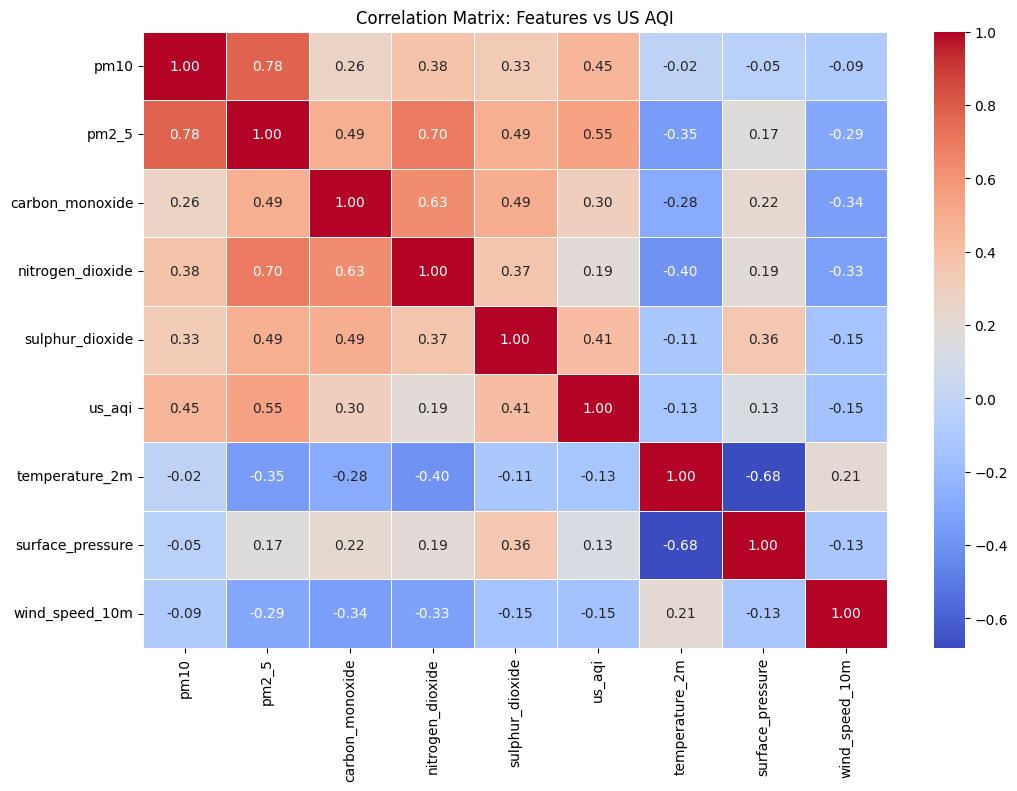


--- [CORRELATIONS WITH US_AQI] ---
us_aqi              1.000000
pm2_5               0.546734
pm10                0.451188
sulphur_dioxide     0.414352
carbon_monoxide     0.303158
nitrogen_dioxide    0.190677
surface_pressure    0.126789
temperature_2m     -0.132295
wind_speed_10m     -0.152658
Name: us_aqi, dtype: float64

 Weak Features (Impact < 0.1):
[]

 Dropped 0 weak features from the dataset.


In [ ]:
plt.figure(figsize=(12, 8))

# 1. Prepare Data (Drop non-numeric columns like 'time')
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# 2. Visualize with Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title(f"Correlation Matrix: Features vs US AQI")
plt.show()

# 3. Focus on Target: us_aqi
print("\n--- [CORRELATIONS WITH US_AQI] ---")
aqi_corr = corr_matrix['us_aqi'].sort_values(ascending=False)
print(aqi_corr)

# 4. Identify Weak Features (Correlation between -0.1 and 0.1)
threshold = 0.1
weak_features = aqi_corr[abs(aqi_corr) < threshold].index.tolist()

print(f"\n Weak Features (Impact < {threshold}):")
print(weak_features)

#5.  Drop unimportant features
df = df.drop(columns=weak_features)
print(f"\n Dropped {len(weak_features)} weak features from the dataset.")


## 🧹 4. Data Cleaning (Backfill & Handle Missing)
We fill the missing values to ensure the dataset is continuous.

In [18]:
print(f"Cleaning data... Initial Nulls: {df.isnull().sum().sum()}")

# 1. Sort by time to ensure backfill makes sense chronologically
df = df.sort_values(by='time')

# 2. Apply Backfill and Forward-fill
df = df.bfill().ffill()

print(f"Cleaned. Remaining Nulls: {df.isnull().sum().sum()}")

df.describe()

Cleaning data... Initial Nulls: 0
Cleaned. Remaining Nulls: 0


,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,us_aqi,temperature_2m,surface_pressure,wind_speed_10m
count,13176,13176.000000,13176.000000,13176.000000,13176.000000,13176.000000,13176.000000,13176.000000,13176.000000,13176.000000
mean,2025-08-14 11:29:59.999999744,49.906019,39.177543,1009.425774,41.750243,12.799271,112.284684,20.432377,945.133515,6.457157
min,2024-11-13 00:00:00,3.200000,3.200000,14.000000,0.000000,1.300000,41.000000,2.700000,930.500000,0.000000
25%,2025-03-30 05:45:00,28.900000,22.400000,472.000000,14.800000,6.800000,86.000000,14.100000,941.375000,3.700000
50%,2025-08-14 11:30:00,42.000000,33.800000,753.000000,32.800000,10.800000,108.000000,20.000000,945.900000,5.900000
75%,2025-12-29 17:15:00,62.400000,50.325000,1352.000000,62.800000,16.300000,142.000000,26.200000,949.100000,8.600000
max,2026-05-15 23:00:00,501.100000,170.900000,5420.000000,151.500000,54.200000,206.000000,44.000000,960.000000,30.600000
std,NaN,31.502490,23.091539,736.066894,32.813421,8.179415,32.021152,7.536476,5.141577,3.830380


## 💾 5. Save Cleaned Data
We save this as the foundation for our Feature Engineering phase.

In [20]:
cleaned_path = ROOT_DIR / "backend/data/cleaned_historical_data.csv"
df.to_csv(cleaned_path, index=False)

print(f" SUCCESS: Cleaned data saved to {cleaned_path}")

 SUCCESS: Cleaned data saved to C:\Users\Dell\Desktop\AirLyst\backend\data\cleaned_historical_data.csv
